# Neural Collaborative Filtering (NCF)

A self-contained pipeline that trains a genre-aware Neural CF model (He et al. 2017,
extended with genre side-features) on the MovieLens-25M ratings, selects the
best epoch on a held-out validation split, and reports a single final test
metric.

Pipeline: **data import → per-user temporal split → integer encoding →
validation split & rating normalisation → on-GPU batcher → NCF model →
training (early stopping) → final test evaluation → per-user showcase.**

In [1]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Data Import
Only the lightweight columns NCF needs: ratings (userId, movieId, rating,
timestamp) plus per-movie genres.

In [2]:
DATA_DIR = Path("../movies-database")

movies  = pd.read_csv(DATA_DIR / "movies.csv")
ratings = pd.read_csv(DATA_DIR / "ratings.csv")

print("movies: ", movies.shape)
print("ratings:", ratings.shape)

movies:  (62423, 3)
ratings: (25000095, 4)


In [5]:
# Training spine: ratings + per-movie genres only (genome stays out).
train = (
    ratings[["userId", "movieId", "rating", "timestamp"]]
    .merge(movies[["movieId", "genres"]], on="movieId", how="left")
)
print(train.shape)

(25000095, 5)


## Genre One-Hot
A `movieId`-indexed 0/1 matrix, one column per genre (the
`(no genres listed)` bucket is dropped). These become the NCF side-features.

In [6]:
genre_dummies = (
    movies.set_index("movieId")["genres"]
    .str.get_dummies("|")
    .drop(columns=["(no genres listed)"], errors="ignore")
    .add_prefix("genre_")
    .astype("int8")
)
print(genre_dummies.shape)

(62423, 19)


## Train / Test Split
Per-user temporal split: for each user, sort their ratings by time and hold out
their last ~20% as test. Splitting *within* each user's timeline (rather than at
a global timestamp cutoff) keeps almost every user evaluable while still
respecting temporal order within that user's history (their test ratings always
come after their train ratings).

A movie that appears only in held-out tails and never in training is dropped
from the test set (movie cold-start).

In [7]:
TEST_FRAC = 0.20

train_sorted = train.sort_values(["userId", "timestamp"], kind="mergesort")

user_rank  = train_sorted.groupby("userId").cumcount()
user_count = train_sorted.groupby("userId")["userId"].transform("size")

# Last ceil(TEST_FRAC * n) ratings per user -> test. Users with too few ratings
# for that to be >= 1 land entirely in train.
test_mask = user_rank >= np.ceil(user_count * (1 - TEST_FRAC))

df_train = train_sorted[~test_mask].copy()
df_test  = train_sorted[test_mask].copy()

# Drop movie cold-start rows from test.
known_movies = set(df_train["movieId"])
n_before = len(df_test)
df_test = df_test[df_test["movieId"].isin(known_movies)].copy()

print(f"Train : {len(df_train):>10,}  rows  ({len(df_train)/len(train):.1%})")
print(f"Test  : {len(df_test):>10,}  rows  ({len(df_test)/len(train):.1%})")
print(f"Dropped from test (movie cold-start): {n_before - len(df_test):,}")

Train : 20,062,533  rows  (80.2%)
Test  :  4,925,572  rows  (19.7%)
Dropped from test (movie cold-start): 11,990


## Genre Side-Features
Attach the genre one-hots to each rating row. `genre_dummies` is indexed by
`movieId`, so a plain join works. Movies with no genre listing get zeros.

In [8]:
GENRE_COLS = genre_dummies.columns.tolist()
N_GENRES   = len(GENRE_COLS)

df_train = df_train.join(genre_dummies, on="movieId")
df_test  = df_test.join(genre_dummies,  on="movieId")

df_train[GENRE_COLS] = df_train[GENRE_COLS].fillna(0).astype("float32")
df_test[GENRE_COLS]  = df_test[GENRE_COLS].fillna(0).astype("float32")

print(f"Genre columns added: {N_GENRES}")

Genre columns added: 19


## Integer Encoding
Embedding layers require contiguous 0-based integer indices. Build the lookup
dicts from the **training set only** so test never leaks new IDs into the
vocabulary.

In [9]:
user_ids  = np.sort(df_train["userId"].unique())
movie_ids = np.sort(df_train["movieId"].unique())

user_to_idx  = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

N_USERS  = len(user_to_idx)
N_MOVIES = len(movie_to_idx)

for df in [df_train, df_test]:
    df["user_idx"]  = df["userId"].map(user_to_idx).astype("int32")
    df["movie_idx"] = df["movieId"].map(movie_to_idx).astype("int32")

print(f"N_USERS={N_USERS:,}   N_MOVIES={N_MOVIES:,}")

N_USERS=162,541   N_MOVIES=51,231


## Validation Split & Rating Normalisation
`df_train` is split once more, per-user, into `df_fit` (what NCF actually trains
on) and `df_val` (held out for early-stopping / best-epoch selection). `df_test`
is reserved for a single final evaluation at the very end.

`user_mean_map` is fit on `df_fit` only. Training targets are
`rating_norm = rating - user_mean`, which is better-conditioned than the raw
star rating; the per-user mean is added back at evaluation time so metrics stay
on the familiar 1-5 scale. Fitting the map on `df_fit` alone keeps val/test
denormalisation leakage-free.

In [10]:
VAL_FRAC = 0.10

def per_user_temporal_split(df, frac, group_col="userId", time_col="timestamp"):
    df_sorted = df.sort_values([group_col, time_col], kind="mergesort")
    rank  = df_sorted.groupby(group_col).cumcount()
    count = df_sorted.groupby(group_col)[group_col].transform("size")
    mask  = rank >= np.ceil(count * (1 - frac))
    return df_sorted[~mask].copy(), df_sorted[mask].copy()

df_fit, df_val = per_user_temporal_split(df_train, VAL_FRAC)

print(f"Fit (train) : {len(df_fit):>10,}  rows  ({len(df_fit)/len(df_train):.1%} of df_train)")
print(f"Validation  : {len(df_val):>10,}  rows  ({len(df_val)/len(df_train):.1%} of df_train)")

Fit (train) : 18,128,361  rows  (90.4% of df_train)
Validation  :  1,934,172  rows  (9.6% of df_train)


In [11]:
# user_mean_map from df_fit ONLY. rating_norm for fit/val/test all centre on
# this one map, so val/test denormalisation is leakage-free.
user_mean_map = df_fit.groupby("user_idx")["rating"].mean()

for df in [df_fit, df_val, df_test]:
    df["rating_norm"] = (df["rating"] - df["user_idx"].map(user_mean_map)).astype("float32")

print("rating_norm computed for df_fit / df_val / df_test")

rating_norm computed for df_fit / df_val / df_test


## Config & On-GPU Batcher
The whole dataset fits in GPU memory, so every column is moved to the device
**once** and mini-batches are pure index slices. This skips DataLoader worker
processes and avoids a CPU→GPU copy on every batch — both faster and more robust
for this workload.

In [12]:
SAMPLE_FRAC  = 1      # 1.0 for full run; 0.10 for a fast smoke-test on CPU
BATCH_SIZE   = 4096
LR           = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [13]:
class GPUBatcher:
    def __init__(self, df, genre_cols, device, batch_size, shuffle=True):
        self.u = torch.tensor(df["user_idx"].values,    dtype=torch.long,    device=device)
        self.m = torch.tensor(df["movie_idx"].values,   dtype=torch.long,    device=device)
        # rating_norm (user-mean-centred) is the training target.
        self.r = torch.tensor(df["rating_norm"].values, dtype=torch.float32, device=device)
        self.g = torch.tensor(df[genre_cols].values,    dtype=torch.float32, device=device)
        self.n, self.bs, self.shuffle = len(self.r), batch_size, shuffle

    def __len__(self):
        return (self.n + self.bs - 1) // self.bs

    def __iter__(self):
        idx = (torch.randperm(self.n, device=self.u.device) if self.shuffle
               else torch.arange(self.n, device=self.u.device))
        for i in range(0, self.n, self.bs):
            j = idx[i:i + self.bs]
            yield self.u[j], self.m[j], self.r[j], self.g[j]


df_tr_sample = df_fit.sample(frac=SAMPLE_FRAC, random_state=42)

train_dl = GPUBatcher(df_tr_sample, GENRE_COLS, DEVICE, BATCH_SIZE, shuffle=True)
val_dl   = GPUBatcher(df_val,       GENRE_COLS, DEVICE, BATCH_SIZE, shuffle=False)
test_dl  = GPUBatcher(df_test,      GENRE_COLS, DEVICE, BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dl):,}   Val batches: {len(val_dl):,}   Test batches: {len(test_dl):,}")

Train batches: 4,426   Val batches: 473   Test batches: 1,203


In [14]:
# Per-user mean rating, indexed by user_idx — used to denormalise rating_norm
# predictions/targets back to the 1-5 star scale during evaluation.
user_means_tensor = torch.tensor(
    user_mean_map.reindex(range(N_USERS)).values.astype("float32"),
    device=DEVICE,
)
print(f"user_means_tensor: {user_means_tensor.shape}")

user_means_tensor: torch.Size([162541])


## Neural CF Model (GMF + MLP)
He et al. (2017), extended with genre side-features. Two separate embedding
spaces:

- **GMF path** — element-wise product of the user embedding and
  (movie embedding + projected genre vector).
- **MLP path** — `concat(u_mlp, m_mlp, genre_raw)` fed through an MLP tower.

The two paths are fused before a single linear output layer.

In [15]:
class NeuralCF(nn.Module):
    """GMF path: element-wise product of user & (movie + genre_proj).
    MLP path: concat(u_mlp, m_mlp, genre) fed into the MLP tower."""
    def __init__(self, n_users, n_movies,
                 n_factors_gmf=32, n_factors_mlp=32,
                 mlp_hidden=(128, 64, 32), n_genres=N_GENRES):
        super().__init__()
        self.u_gmf = nn.Embedding(n_users,  n_factors_gmf)
        self.m_gmf = nn.Embedding(n_movies, n_factors_gmf)
        self.u_mlp = nn.Embedding(n_users,  n_factors_mlp)
        self.m_mlp = nn.Embedding(n_movies, n_factors_mlp)
        self.genre_proj_gmf = nn.Linear(n_genres, n_factors_gmf, bias=False)
        # MLP input: concat(u_mlp, m_mlp, genre_raw) = 2*n_factors_mlp + n_genres
        dims = [2 * n_factors_mlp + n_genres, *mlp_hidden]
        self.mlp = nn.Sequential(*[
            layer
            for in_d, out_d in zip(dims, dims[1:])
            for layer in (nn.Linear(in_d, out_d), nn.ReLU())
        ])
        self.output_layer = nn.Linear(n_factors_gmf + mlp_hidden[-1], 1)
        for emb in (self.u_gmf, self.m_gmf, self.u_mlp, self.m_mlp):
            nn.init.normal_(emb.weight, std=0.01)
        nn.init.normal_(self.genre_proj_gmf.weight, std=0.01)

    def forward(self, u, m, g):
        gmf_out = self.u_gmf(u) * (self.m_gmf(m) + self.genre_proj_gmf(g))
        mlp_out = self.mlp(torch.cat([self.u_mlp(u), self.m_mlp(m), g], dim=1))
        return self.output_layer(torch.cat([gmf_out, mlp_out], dim=1)).squeeze(1)


print("Model defined.")

Model defined.


## Training & Evaluation
`evaluate` runs one pass over a loader and, when `user_means` is supplied,
denormalises both predictions and targets back to the 1-5 scale (clipping
predictions to `[0.5, 5.0]`). `train_model` runs the epoch loop with early
stopping driven entirely by validation RMSE, restoring the best-epoch weights
before returning.

In [16]:
def evaluate(model, dl, device, user_means=None):
    """Run model over every batch; return (preds, true, rmse, mae).

    If user_means is given, predictions and targets are denormalised
    (rating_norm -> 1-5 star scale) and predictions clipped to [0.5, 5.0].
    """
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for u, m, r, g in dl:
            preds = model(u, m, g)
            if user_means is not None:
                means = user_means[u]
                preds = preds + means
                r     = r + means
            preds_all.append(preds.cpu())
            true_all.append(r.cpu())
    preds_t = torch.cat(preds_all).numpy()
    true_t  = torch.cat(true_all).numpy()
    if user_means is not None:
        preds_t = np.clip(preds_t, 0.5, 5.0)
    rmse = float(np.sqrt(np.mean((preds_t - true_t) ** 2)))
    mae  = float(np.mean(np.abs(preds_t - true_t)))
    return preds_t, true_t, rmse, mae


def train_model(model, train_dl, val_dl, device, lr, weight_decay, label,
                patience=5, user_means=None, max_epochs=100):
    """Train until validation RMSE stops improving for `patience` epochs, then
    restore the best-epoch weights. df_test is never seen here."""
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    n_train   = train_dl.n

    results      = []
    best_rmse    = float("inf")
    best_weights = None
    epochs_stale = 0

    for epoch in range(1, max_epochs + 1):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for u, m, r, g in train_dl:
            optimiser.zero_grad()
            loss = criterion(model(u, m, g), r)
            loss.backward()
            optimiser.step()
            train_loss += loss.item() * len(r)
        train_rmse = (train_loss / n_train) ** 0.5

        # ── Validation ────────────────────────────────────────────────────
        _, _, val_rmse, val_mae = evaluate(model, val_dl, device, user_means)
        results.append({"epoch": epoch, "train_rmse": train_rmse,
                        "val_rmse": val_rmse, "val_mae": val_mae})

        # ── Early-stopping bookkeeping ────────────────────────────────────
        if val_rmse < best_rmse:
            best_rmse    = val_rmse
            best_weights = copy.deepcopy(model.state_dict())
            epochs_stale = 0
            tag = " ✓"
        else:
            epochs_stale += 1
            tag = f" (no improvement {epochs_stale}/{patience})"

        print(f"[{label}] Epoch {epoch}  "
              f"train_RMSE={train_rmse:.4f}  "
              f"val_RMSE={val_rmse:.4f}  "
              f"val_MAE={val_mae:.4f}{tag}")

        if epochs_stale >= patience:
            print(f"[{label}] Early stopping at epoch {epoch} — "
                  f"no improvement for {patience} epochs. "
                  f"Best val RMSE={best_rmse:.4f} (epoch {epoch - patience}).")
            break
    else:
        print(f"[{label}] Reached max_epochs={max_epochs} without early "
              f"stopping. Using best epoch so far (val RMSE={best_rmse:.4f}).")

    model.load_state_dict(best_weights)
    return results

## Train NCF
Train the model, select the best epoch on `df_val`, then touch `df_test` exactly
once with the best-by-validation weights for the final reported metric.

In [17]:
model_ncf = NeuralCF(N_USERS, N_MOVIES, n_factors_gmf=32, n_factors_mlp=32,
                     n_genres=N_GENRES).to(DEVICE)
results_ncf = train_model(
    model_ncf, train_dl, val_dl, DEVICE, LR, WEIGHT_DECAY, label="NCF",
    user_means=user_means_tensor
)

# Final test evaluation — touched once, with the best-by-validation weights.
ncf_test_preds, ncf_test_true, ncf_test_rmse, ncf_test_mae = evaluate(
    model_ncf, test_dl, DEVICE, user_means=user_means_tensor
)
print(f"[NCF] FINAL test_RMSE={ncf_test_rmse:.4f}  test_MAE={ncf_test_mae:.4f}  (test touched once)")

[NCF] Epoch 1  train_RMSE=0.8290  val_RMSE=0.8159  val_MAE=0.6157 ✓
[NCF] Epoch 2  train_RMSE=0.7835  val_RMSE=0.7976  val_MAE=0.6011 ✓
[NCF] Epoch 3  train_RMSE=0.7588  val_RMSE=0.7899  val_MAE=0.5950 ✓
[NCF] Epoch 4  train_RMSE=0.7444  val_RMSE=0.7868  val_MAE=0.5922 ✓
[NCF] Epoch 5  train_RMSE=0.7364  val_RMSE=0.7858  val_MAE=0.5913 ✓
[NCF] Epoch 6  train_RMSE=0.7317  val_RMSE=0.7852  val_MAE=0.5909 ✓
[NCF] Epoch 7  train_RMSE=0.7287  val_RMSE=0.7854  val_MAE=0.5901 (no improvement 1/5)
[NCF] Epoch 8  train_RMSE=0.7265  val_RMSE=0.7844  val_MAE=0.5907 ✓
[NCF] Epoch 9  train_RMSE=0.7247  val_RMSE=0.7846  val_MAE=0.5900 (no improvement 1/5)
[NCF] Epoch 10  train_RMSE=0.7234  val_RMSE=0.7849  val_MAE=0.5895 (no improvement 2/5)
[NCF] Epoch 11  train_RMSE=0.7223  val_RMSE=0.7842  val_MAE=0.5899 ✓
[NCF] Epoch 12  train_RMSE=0.7214  val_RMSE=0.7853  val_MAE=0.5896 (no improvement 1/5)
[NCF] Epoch 13  train_RMSE=0.7207  val_RMSE=0.7853  val_MAE=0.5895 (no improvement 2/5)
[NCF] Epoch 14  t

## Confusion Matrix

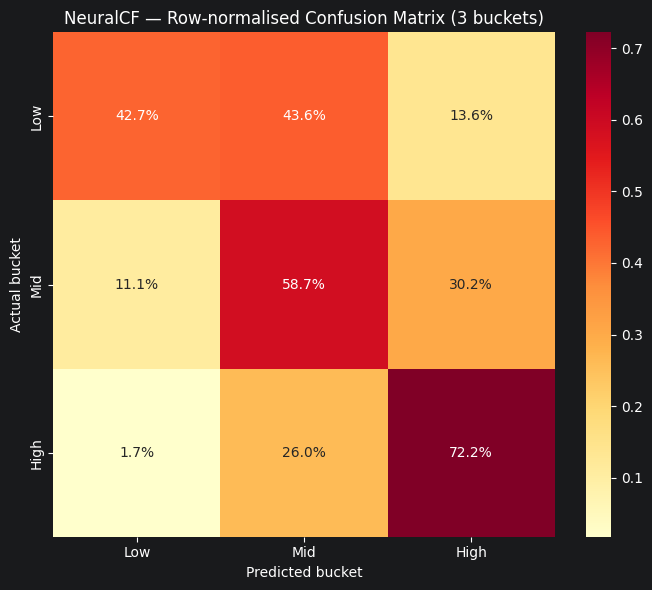

In [18]:
def bucket(ratings):
    # Right-OPEN intervals so each boundary lands in the bucket its label names:
    #   Low  = [0.5, 2.5)   Mid = [2.5, 3.5)   High = [3.5, 5.0]
    # (a 2.5 is "Mid", a 3.5 is "High" — matching the printed labels).
    return pd.cut(
        ratings,
        bins=[0.5, 2.5, 3.5, 5.01],
        labels=["Low (<2.5)", "Mid (2.5-3.5)", "High (3.5-5.0)"],
        right=False,
        include_lowest=True,
    )

# Clip both arrays into the valid rating range before bucketing so no value
# can fall outside the bins and become NaN (which would break confusion_matrix).
true_buckets = bucket(np.clip(ncf_test_true,  0.5, 5.0))
pred_buckets = bucket(np.clip(ncf_test_preds, 0.5, 5.0))

cm3 = confusion_matrix(true_buckets, pred_buckets,
                        labels=["Low (<2.5)", "Mid (2.5-3.5)", "High (3.5-5.0)"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm3 / cm3.sum(axis=1, keepdims=True),  # row-normalise → recall per class
    annot=True, fmt=".1%", cmap="YlOrRd",
    xticklabels=["Low", "Mid", "High"],
    yticklabels=["Low", "Mid", "High"], ax=ax
)
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("Actual bucket")
ax.set_title("NeuralCF — Row-normalised Confusion Matrix (3 buckets)")
plt.tight_layout()
plt.show()

## Per-User Showcase
For a handful of test users, show what the model learned from, what they
actually liked in the held-out period, and the model's top recommendations:

- **Liked in training** — up to 5 movies rated ≥ 4.0 during training.
- **Rated in test** — high-rated (≥ 4.0) movies from the held-out period.
- **NCF Top-N** — movies the model ranks highest among everything the user has
  *never* rated. A `✓` marks a recommendation the user did like in test.

NCF predicts `rating_norm` (deviation from the user's own average); the user's
mean is added back so the displayed score is on the 1-5 scale. Adding a per-user
constant doesn't change the ranking.

In [19]:
# Lookups needed by the showcase.
idx_to_movie  = {v: k for k, v in movie_to_idx.items()}
all_movie_ids = [idx_to_movie[i] for i in range(N_MOVIES)]
genre_mat     = (genre_dummies
                 .reindex(all_movie_ids)
                 .fillna(0)
                 .values
                 .astype("float32"))          # (N_MOVIES, N_GENRES)

genre_tensor_all = torch.tensor(genre_mat, dtype=torch.float32).to(DEVICE)

movie_title  = movies.set_index("movieId")["title"]
movie_genres = movies.set_index("movieId")["genres"]

In [20]:
N_SAMPLE_USERS = 5
TOP_N          = 5
MIN_LIKED      = 5   # skip users who barely rated anything in training
MIN_TEST_LIKED = 1   # require at least one liked (>=4.0) rating in held-out period

liked_train = df_train[df_train["rating"] >= 4.0]
liked_test  = df_test[df_test["rating"] >= 4.0]

train_counts = liked_train.groupby("user_idx").size()
test_counts  = liked_test.groupby("user_idx").size()

# Eligible: enough liked training history AND at least one liked test rating.
eligible_users = (
    train_counts[train_counts >= MIN_LIKED].index
    .intersection(test_counts[test_counts >= MIN_TEST_LIKED].index)
    .tolist()
)

rng_sc           = np.random.default_rng(42)
sample_user_idxs = rng_sc.choice(eligible_users, size=N_SAMPLE_USERS, replace=False)

model_ncf.eval()

def fmt_movie(mid, extra=""):
    title  = movie_title.get(mid, "Unknown")
    genres = movie_genres.get(mid, "")
    genres_short = ", ".join(genres.split("|")[:3])
    return f"{title}  [{genres_short}]{extra}"

sep = "─" * 80

for u_idx in sample_user_idxs:
    print(sep)
    print(f"  USER  idx={u_idx}")
    print(sep)

    # ── Liked in training ──────────────────────────────────────────────────
    liked_train_rows = (
        liked_train[liked_train["user_idx"] == u_idx]
        .nlargest(5, "rating")[["movieId", "rating"]]
    )
    print("  ★ LIKED IN TRAINING (top-5 rated ≥ 4.0):")
    for _, row in liked_train_rows.iterrows():
        print(f"      {row['rating']:.1f}★  {fmt_movie(int(row['movieId']))}")

    # ── Rated in test ──────────────────────────────────────────────────────
    liked_test_rows = (
        liked_test[liked_test["user_idx"] == u_idx]
        .nlargest(5, "rating")[["movieId", "rating"]]
    )
    test_liked_movie_ids = set(liked_test_rows["movieId"])
    print("\n  ✓ RATED IN TEST (top-5 rated ≥ 4.0, held-out period):")
    for _, row in liked_test_rows.iterrows():
        print(f"      {row['rating']:.1f}★  {fmt_movie(int(row['movieId']))}")

    # ── NCF recommendations: score all unrated movies ──────────────────────
    rated_set = set(df_train[df_train["user_idx"] == u_idx]["movie_idx"].values)
    unrated   = [i for i in range(N_MOVIES) if i not in rated_set]
    u_t       = torch.full((len(unrated),), u_idx, dtype=torch.long).to(DEVICE)
    m_t       = torch.tensor(unrated, dtype=torch.long).to(DEVICE)
    g_t       = genre_tensor_all[m_t]
    with torch.no_grad():
        scores_norm = model_ncf(u_t, m_t, g_t).cpu().numpy()

    user_mean = user_means_tensor[u_idx].item()
    scores    = np.clip(scores_norm + user_mean, 0.5, 5.0)
    top_k_pos = np.argsort(scores)[::-1][:TOP_N]

    print(f"\n  NCF TOP-{TOP_N} RECOMMENDATIONS (unrated movies, by predicted score):")
    for rank, pos in enumerate(top_k_pos, 1):
        mid   = idx_to_movie[unrated[pos]]
        score = scores[pos]
        hit   = "  ✓ liked in test" if mid in test_liked_movie_ids else ""
        print(f"      {rank:>2}. ({score:+.2f})  {fmt_movie(mid, hit)}")

    print()

print(sep)

────────────────────────────────────────────────────────────────────────────────
  USER  idx=125813
────────────────────────────────────────────────────────────────────────────────
  ★ LIKED IN TRAINING (top-5 rated ≥ 4.0):
      5.0★  Pulp Fiction (1994)  [Comedy, Crime, Drama]
      5.0★  Seven (a.k.a. Se7en) (1995)  [Mystery, Thriller]
      5.0★  Taxi Driver (1976)  [Crime, Drama, Thriller]
      5.0★  Birdcage, The (1996)  [Comedy]
      5.0★  Clerks (1994)  [Comedy]

  ✓ RATED IN TEST (top-5 rated ≥ 4.0, held-out period):
      5.0★  Smoke (1995)  [Comedy, Drama]
      4.0★  Aristocats, The (1970)  [Animation, Children]
      4.0★  Jungle Book, The (1994)  [Adventure, Children, Romance]

  NCF TOP-5 RECOMMENDATIONS (unrated movies, by predicted score):
       1. (+4.78)  Planet Earth (2006)  [Documentary]
       2. (+4.78)  Usual Suspects, The (1995)  [Crime, Mystery, Thriller]
       3. (+4.75)  Planet Earth II (2016)  [Documentary]
       4. (+4.71)  Shawshank Redemption, The (

## Save the model weights + metadata lookups

In [ ]:
# 1. Save the model weights
torch.save(model_ncf.state_dict(), "../docker-app/services/mlengine/ncf_weights.pth")

# 2. Save the metadata lookups
metadata = {
    "N_USERS": N_USERS,
    "N_MOVIES": N_MOVIES,
    "movie_to_idx": movie_to_idx,
    "idx_to_movie": {v: k for k, v in movie_to_idx.items()},
    "N_GENRES": N_GENRES
}

with open("../docker-app/services/mlengine/ncf_metadata.pkl", "wb") as f:
    pickle.dump(metadata, f)